Group 7: Leen Alnajjar, Suyeon Choi, Taebin Sung, Ziyu Wang

In [1]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
%matplotlib inline

print("packages imported")

packages imported


# Problem Statement

Build a linear regression model of the duration of sleep, given the time engaged in physical activity, stress level, and quality of sleep.

# Variables and Parameters

| Description | Symbol | Dimension
| :---: | :---: | :---: |
| Regression coefficient for intercept | $\beta_0$ | T |
| Time engaged in physical activity | $X_1$ | T |
| Regression coefficient for time for physical activity | $\beta_1$ | 1 |
| Stress level | $X_2$ | 1 |
| Regression coefficient for stress level | $\beta_2$ | T |
| Sleep quality | $X_3$ |  1 |
| Regression coefficient for sleep quality | $\beta_3$ |  T |
| Total number of hours slept |  $Y$ | T |
| Error | $\varepsilon$ | T |

# Assumptions and Constraints

- The model follows the linear model $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \varepsilon$.
- The average value of the error is 0: i.e., $\mathbb{E}(\epsilon_i) = 0$ for all $i$
- The variance of the error is constant: i.e., $Var(\epsilon_i) = \sigma^2$ for all $i$.
- The error $\vec{\epsilon}$ is a random sample from the normal distribution of zero mean and variance $\sigma^2$.
- The error is independent for each $\epsilon_i$ for all $i$.
- Other factors (i.e., plans on the following day) are negligible.
- All participants are independent from one another.
- All data has been collected on the same day.
- Total number of sleep is non-negative.
- The self-reported data are given a clear criteria so there is small variation in values to how they actually feel.

# Building Solutions

We build the linear regression: $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \varepsilon$

In [2]:
#import data 
sleep = pd.read_csv('Sleep.csv')
sleep = pd.DataFrame(sleep)
sleep.head()

,Duration,Quality,Physical_Activity,Stress
0,6.1,6,42,6
1,6.2,6,60,8
2,6.2,6,60,8
3,5.9,4,30,8
4,5.9,4,30,8


In [3]:
X = sleep[['Quality', 'Physical_Activity', 'Stress']]
Y = sleep['Duration']

In [4]:
X = sm.add_constant(X)
reg = sm.OLS(Y,X).fit()
summary_table = reg.summary()
print(summary_table)

                            OLS Regression Results                            
Dep. Variable:               Duration   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     450.5
Date:                Thu, 04 Dec 2025   Prob (F-statistic):          4.13e-123
Time:                        04:06:03   Log-Likelihood:                -157.20
No. Observations:                 374   AIC:                             322.4
Df Residuals:                     370   BIC:                             338.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.6737      0.40

# Analyze and Assess

To check our assumptions on the error of the linear regression, we will produce the diagnostic plots.

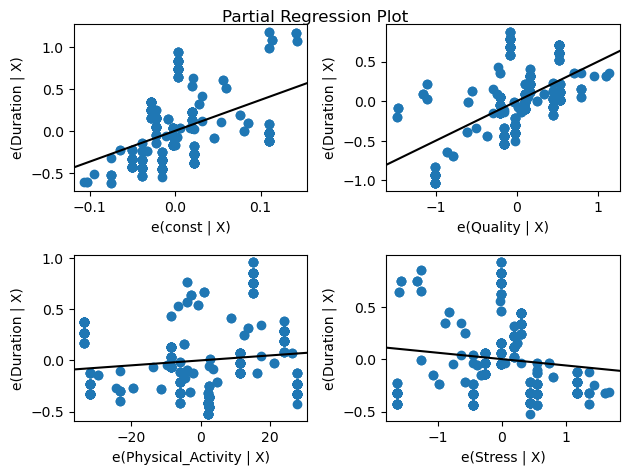

In [5]:
# Assumption: average value of the error is zero.
## partial regression plots
sm.graphics.plot_partregress_grid(reg)
plt.show()

**TO-DO**: analysis on this pre-transformation partial regression plot (ZIYU)

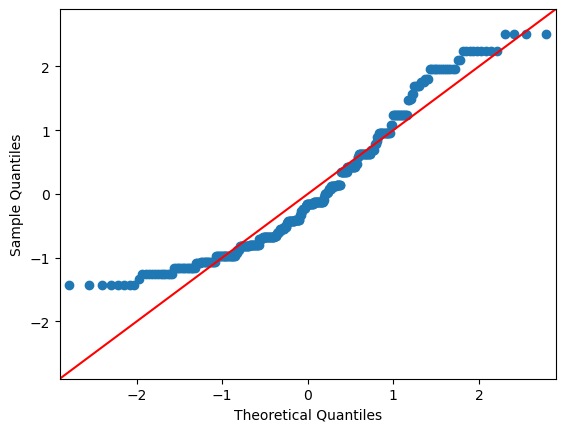

In [6]:
## Errors are normally distributed

## normal QQ plot
residuals = reg.resid

sm.qqplot(residuals,fit=True, line="45")
plt.show()

**TO-DO** Pre-transformation QQ plot analysis (ZIYU)

**TO-DO**: analysis on rest of the plots (not included here; see the other file)

## Transformation

Based on the pre-transformation diagnostics, we experimented with several transformations suggested in the assignment. After performing a process of elimination, we found that applying the following transformation provided the ____(reason to choose these transformation)_____: **squared stress level**, `Sqr_Stress`, and square of sleep quality, `Sqr_Quality`. This leads to the transformed model $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2^2 + \beta_3 X_3^2 + \varepsilon.$$

In [7]:
# TRANSFORMATION: sqrt(stress), log(quality)

sleep["Sqr_Stress"] = sleep["Stress"]**2
# sleep["Sqrt_Stress"] = np.sqrt(sleep["Stress"])

# sleep["Log_Quality"] = np.log(sleep["Quality"])
sleep["Sqr_Quality"] = sleep["Quality"]**2

# sleep["Log_Duration"]  = np.log(sleep["Duration"])
# sleep["Sqrt_Duration"] = np.sqrt(sleep["Duration"])

In [8]:
X2 = sleep[['Sqr_Quality','Physical_Activity','Sqr_Stress']]
Y2 = sleep[['Duration']]

X2 = sm.add_constant(X2)

reg_2 = sm.OLS(Y2,X2).fit()

summary_table=reg_2.summary()
print(summary_table)

                            OLS Regression Results                            
Dep. Variable:               Duration   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     495.7
Date:                Thu, 04 Dec 2025   Prob (F-statistic):          3.29e-129
Time:                        04:06:04   Log-Likelihood:                -143.00
No. Observations:                 374   AIC:                             294.0
Df Residuals:                     370   BIC:                             309.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.2809      0.18

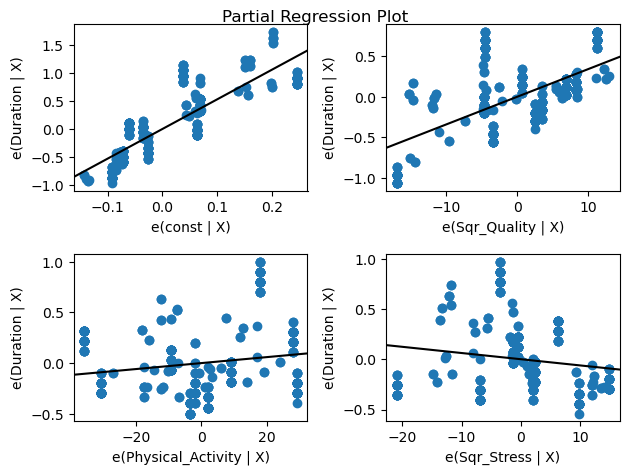

In [9]:
# Assumption: average value of the error is zero.
## partial regression plots
sm.graphics.plot_partregress_grid(reg_2)
plt.show()

**TO-DO**: Explain how this partial regresison plot changed comapred to pre (SUYEON)

Key thing to note here is that, after applying the combination of transformations, the partial regression plot for the sleep quality shows a more linear pattern with more tightly concentrated points around the line. This indicates that the linearity assumption is better satisfied for the transformed model.

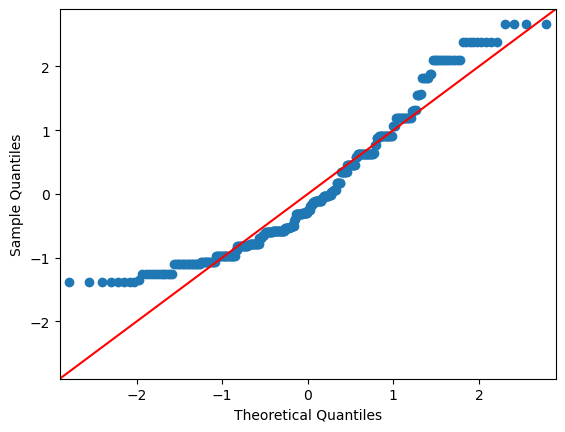

In [10]:
## Errors are normally distributed

## normal QQ plot
residuals_2 = reg_2.resid

sm.qqplot(residuals_2,fit=True, line="45")
plt.show()

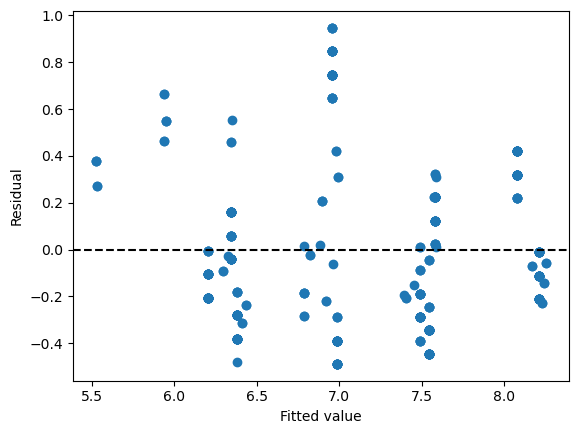

In [12]:
fitted_y = reg_2.fittedvalues

residuals = reg_2.resid

plt.scatter(fitted_y,residuals)
plt.axhline(y = 0, color = 'k', linestyle = '--')
plt.xlabel('Fitted value')
plt.ylabel('Residual')
plt.show()

**TO-DO**: Explain how this transformation is better than original (SUYEON)

In this residuals-fitted plot, the centres of the strands of each point are much closer to a flat line, meaning it shows less curvature. Although the improvement is not dramatic, this still supports our choice of transformation, as the constant-variance assumption is better satified on the transformed model.

**TO-DO**: Explain that other (those not included) plots show minimal changes (effects)



### Observations and Analysis

**TO-DO**: summary table explanation (adjusted r squared, significant factors – beta coefficients) (TAEBIN)

The linear regression is therefore $\hat Y = $. **TO-DO**

### Model Limitations

LEEN **TO-DO**